# E→E backbone comparison with and without self-connections

This notebook loads `mij_matrix.csv`, classifies excitatory senders from the sign of outgoing weights, then compares:

1. greedy strongest outgoing simple path,
2. maximum spanning tree backbone,
3. bounded branch-and-bound path search,
4. beam dynamic-programming path search.

Each method is run under both `no_self` and `with_self`. The notebook writes comparison tables, stepwise greedy path printouts, and network plots for visual inspection.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

INPUT_CSV = "mij_matrix.csv"
OUTDIR = Path("ee_backbone_compare_self_modes")
PLOTDIR = OUTDIR / "plots"
OUTDIR.mkdir(exist_ok=True)
PLOTDIR.mkdir(exist_ok=True)

# Practical controls
BB_MAX_EXPANSIONS = 300        # bounded branch-and-bound; raise for deeper search
BB_TOP_K_PER_NODE = 4          # branching factor cap
DP_BEAM_WIDTH = 75             # beam-limited dynamic programming states per depth

# Plot controls
VISUALIZE_ALL_SEEDS = False
VISUALIZE_SEEDS = None         # None means first 3 excitatory seeds
MAX_INLINE_FIGURES = 6


In [2]:
W = pd.read_csv(INPUT_CSV, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
assert W.shape[0] == W.shape[1]
assert list(W.index) == list(W.columns)

# Excitatory senders: in this matrix, positive outgoing weights encode excitatory signal.
E_nodes = list(W.index[(W > 0).any(axis=1)])
W_EE_raw = W.loc[E_nodes, E_nodes].clip(lower=0.0)

print(f"Loaded {W.shape[0]}x{W.shape[1]} matrix.")
print(f"Identified {len(E_nodes)} excitatory nodes.")
display(pd.DataFrame({"excitatory_node": E_nodes}).head(40))

node_sign_summary = pd.DataFrame({
    "node": W.index,
    "n_positive_out": (W > 0).sum(axis=1).values,
    "n_negative_out": (W < 0).sum(axis=1).values,
    "positive_out_sum": W.clip(lower=0).sum(axis=1).values,
    "negative_out_sum": W.clip(upper=0).sum(axis=1).values,
    "is_excitatory": [n in E_nodes for n in W.index],
})
node_sign_summary.to_csv(OUTDIR / "node_sign_summary.csv", index=False)


Loaded 85x85 matrix.
Identified 32 excitatory nodes.


,excitatory_node
0,CA1 Pyramidal
1,CA1 Radiatum Giant
2,CA2 Pyramidal
3,CA3 Granule
4,CA3 Pyramidal
5,CA3c Pyramidal
6,DG Granule
7,DG Hilar Ectopic Granule
8,DG Mossy
9,DG Semilunar Granule


In [3]:
def condition_matrix(condition):
    M = W_EE_raw.copy().astype(float)
    diag = pd.Series(np.diag(M.values).copy(), index=M.index).clip(lower=0.0)
    np.fill_diagonal(M.values, 0.0)  # self-connections are scored as node rewards, not transitions
    if condition == "no_self":
        self_w = pd.Series(0.0, index=M.index)
    elif condition == "with_self":
        self_w = diag
    else:
        raise ValueError(condition)
    return M, self_w

positive_self = pd.DataFrame({
    "node": W_EE_raw.index,
    "positive_self_weight": np.diag(W_EE_raw.values),
}).query("positive_self_weight > 0")
positive_self.to_csv(OUTDIR / "positive_self_connections.csv", index=False)
print(f"Positive E→E self-connections: {len(positive_self)}")
display(positive_self.head(30))


Positive E→E self-connections: 27


,node,positive_self_weight
0,CA1 Pyramidal,2793.755517
2,CA2 Pyramidal,2163.138289
4,CA3 Pyramidal,3278.450766
5,CA3c Pyramidal,639.864070
7,DG Hilar Ectopic Granule,0.921381
8,DG Mossy,1751.260654
9,DG Semilunar Granule,40.604694
10,EC LI II Multipolar Pyramidal,18296.078460
11,EC LI II Pyramidal Fan,370.754461
12,EC LII III Pyramidal Tripolar,2277.297842


In [4]:
def finalize(method, condition, seed, nodes, edges, self_w, status="ok", tree=False):
    if tree:
        termini = sorted(set(nodes) - {e["sender"] for e in edges}) if edges else [seed]
    else:
        termini = [nodes[-1]] if nodes else [seed]
    transition_sum = sum(e["transition_weight"] for e in edges)
    self_sum = float(self_w.loc[list(dict.fromkeys(nodes))].sum()) if nodes else 0.0
    return {
        "method": method, "condition": condition, "seed": seed,
        "nodes": nodes, "edges": edges, "length": len(edges),
        "transition_weight_sum": transition_sum,
        "self_weight_sum": self_sum,
        "summed_weight": transition_sum + self_sum,
        "termini": termini, "status": status,
    }

def greedy(seed, condition, M, self_w):
    nodes=[seed]; visited={seed}; cur=seed; edges=[]; step_rows=[]
    cum=float(self_w.loc[seed])
    step_rows.append({"condition":condition,"seed":seed,"step":0,"sender":None,"receiver":seed,
                      "transition_weight":0.0,"receiver_self_weight":float(self_w.loc[seed]),
                      "increment_weight":float(self_w.loc[seed]),"cumulative_weight":cum})
    step=1
    while True:
        row=M.loc[cur].copy()
        row.loc[list(visited)] = 0.0
        if row.max() <= 0: break
        nxt=row.idxmax()
        ew=float(row.loc[nxt]); sw=float(self_w.loc[nxt]); inc=ew+sw; cum+=inc
        edges.append({"step":step,"sender":cur,"receiver":nxt,"transition_weight":ew,
                      "receiver_self_weight":sw,"increment_weight":inc})
        step_rows.append({"condition":condition,"seed":seed,"step":step,"sender":cur,"receiver":nxt,
                          "transition_weight":ew,"receiver_self_weight":sw,
                          "increment_weight":inc,"cumulative_weight":cum})
        nodes.append(nxt); visited.add(nxt); cur=nxt; step+=1
    out=finalize("greedy",condition,seed,nodes,edges,self_w)
    out["steps"]=step_rows
    return out

def max_spanning_tree(seed, condition, M, self_w):
    # Undirected maximum spanning tree on positive E-E weights; each seed orients the same tree outward.
    G=nx.Graph()
    for u in M.index:
        G.add_node(u)
    arr=M.values; labels=list(M.index)
    for i,u in enumerate(labels):
        for j in range(i+1,len(labels)):
            v=labels[j]
            w=max(float(arr[i,j]), float(arr[j,i]))
            if w>0: G.add_edge(u,v,weight=w)
    if G.number_of_edges()==0:
        return finalize("maximum_spanning_tree",condition,seed,[seed],[],self_w,tree=True)
    component=G.subgraph(nx.node_connected_component(G, seed)).copy()
    T=nx.maximum_spanning_tree(component, weight="weight")
    B=nx.bfs_tree(T, seed)
    edges=[]; nodes=list(B.nodes())
    for k,(u,v) in enumerate(B.edges(), start=1):
        # Use directed weight if present, otherwise the reciprocal undirected support.
        ew=float(M.loc[u,v]) if M.loc[u,v]>0 else float(M.loc[v,u])
        sw=float(self_w.loc[v])
        edges.append({"step":k,"sender":u,"receiver":v,"transition_weight":ew,
                      "receiver_self_weight":sw,"increment_weight":ew+sw})
    return finalize("maximum_spanning_tree",condition,seed,nodes,edges,self_w,tree=True)

def branch_bound(seed, condition, M, self_w):
    best_nodes=[seed]; best_edges=[]; best_score=float(self_w.loc[seed])
    stack=[(seed,[seed],{seed},[],best_score)]
    expansions=0
    while stack and expansions < BB_MAX_EXPANSIONS:
        cur,nodes,visited,edges,score=stack.pop(); expansions += 1
        if score > best_score:
            best_score=score; best_nodes=nodes; best_edges=edges
        candidates=[]
        row=M.loc[cur]
        for nxt,ew in row.items():
            if nxt not in visited and ew>0:
                candidates.append((float(ew)+float(self_w.loc[nxt]),nxt,float(ew)))
        candidates=sorted(candidates, reverse=True)[:BB_TOP_K_PER_NODE]
        # bound is permissive; this remains a bounded B&B search for tractability
        for inc,nxt,ew in candidates:
            sw=float(self_w.loc[nxt])
            new_edges=edges+[{"step":len(edges)+1,"sender":cur,"receiver":nxt,
                              "transition_weight":ew,"receiver_self_weight":sw,
                              "increment_weight":ew+sw}]
            stack.append((nxt,nodes+[nxt],visited|{nxt},new_edges,score+ew+sw))
    status="ok" if expansions < BB_MAX_EXPANSIONS else f"bounded_at_{BB_MAX_EXPANSIONS}_expansions"
    return finalize("branch_bound",condition,seed,best_nodes,best_edges,self_w,status=status)

def dynamic_programming(seed, condition, M, self_w):
    states={(seed,(seed,)):(float(self_w.loc[seed]),[])}
    best_key=(seed,(seed,)); best_score=float(self_w.loc[seed]); best_edges=[]
    for depth in range(len(M.index)-1):
        new={}
        for (last,visited_tuple),(score,edges) in states.items():
            visited=set(visited_tuple)
            row=M.loc[last]
            for nxt,ew in row.items():
                if nxt in visited or ew<=0: continue
                sw=float(self_w.loc[nxt])
                key=(nxt, visited_tuple+(nxt,))
                val=(score+float(ew)+sw, edges+[{"step":len(edges)+1,"sender":last,"receiver":nxt,
                                                "transition_weight":float(ew),
                                                "receiver_self_weight":sw,
                                                "increment_weight":float(ew)+sw}])
                if key not in new or val[0] > new[key][0]:
                    new[key]=val
                if val[0] > best_score:
                    best_score=val[0]; best_key=key; best_edges=val[1]
        if not new: break
        items=sorted(new.items(), key=lambda kv:kv[1][0], reverse=True)[:DP_BEAM_WIDTH]
        states=dict(items)
    nodes=[seed]+[e["receiver"] for e in best_edges]
    return finalize("dynamic_programming_beam",condition,seed,nodes,best_edges,self_w,status=f"beam_width_{DP_BEAM_WIDTH}")


In [5]:
results=[]; edge_rows=[]; greedy_rows=[]
for condition in ["no_self","with_self"]:
    M,self_w=condition_matrix(condition)
    for seed in E_nodes:
        for res in [
            greedy(seed,condition,M,self_w),
            max_spanning_tree(seed,condition,M,self_w),
            branch_bound(seed,condition,M,self_w),
            dynamic_programming(seed,condition,M,self_w),
        ]:
            results.append(res)
            for e in res["edges"]:
                edge_rows.append({**e, "condition":condition, "method":res["method"],
                                  "seed":seed, "termini":"; ".join(res["termini"])})
            if res["method"]=="greedy":
                greedy_rows.extend(res["steps"])

summary=pd.DataFrame([{
    "condition":r["condition"], "method":r["method"], "seed":r["seed"],
    "length":r["length"], "transition_weight_sum":r["transition_weight_sum"],
    "self_weight_sum":r["self_weight_sum"], "summed_weight":r["summed_weight"],
    "termini":"; ".join(r["termini"]), "path_or_tree_nodes":" -> ".join(r["nodes"]),
    "status":r["status"],
} for r in results])
edges_df=pd.DataFrame(edge_rows)
greedy_steps=pd.DataFrame(greedy_rows)

summary.to_csv(OUTDIR/"method_comparison_long.csv", index=False)
edges_df.to_csv(OUTDIR/"all_methods_edges.csv", index=False)
greedy_steps.to_csv(OUTDIR/"greedy_stepwise_paths.csv", index=False)

wide=summary.pivot_table(index=["seed","method"], columns="condition",
                         values=["length","summed_weight","transition_weight_sum","self_weight_sum","termini","status"],
                         aggfunc="first")
wide.columns=[f"{a}_{b}" for a,b in wide.columns]
wide=wide.reset_index()
if "summed_weight_with_self" in wide and "summed_weight_no_self" in wide:
    wide["delta_summed_weight_with_minus_no_self"]=wide["summed_weight_with_self"]-wide["summed_weight_no_self"]
if "length_with_self" in wide and "length_no_self" in wide:
    wide["delta_length_with_minus_no_self"]=wide["length_with_self"]-wide["length_no_self"]
wide.to_csv(OUTDIR/"method_comparison_wide.csv", index=False)

method_summary=summary.groupby(["condition","method"]).agg(
    n_seeds=("seed","nunique"),
    mean_length=("length","mean"),
    median_length=("length","median"),
    mean_summed_weight=("summed_weight","mean"),
    median_summed_weight=("summed_weight","median"),
).reset_index()
method_summary.to_csv(OUTDIR/"method_summary.csv", index=False)

display(method_summary)
display(wide.head(30))


,condition,method,n_seeds,mean_length,median_length,mean_summed_weight,median_summed_weight
0,no_self,branch_bound,32,26.03125,26.5,93323.992207,96542.175151
1,no_self,dynamic_programming_beam,32,16.84375,16.0,210380.700036,217310.332490
2,no_self,greedy,32,16.68750,16.0,125314.241109,121527.333900
3,no_self,maximum_spanning_tree,32,31.00000,31.0,507182.238272,511270.560872
4,with_self,branch_bound,32,23.78125,28.0,105024.679128,102381.117570
5,with_self,dynamic_programming_beam,32,16.03125,16.0,241903.103427,250006.866842
6,with_self,greedy,32,16.68750,16.0,144287.549772,135698.835239
7,with_self,maximum_spanning_tree,32,31.00000,31.0,548630.995279,552719.317879


,seed,method,length_no_self,length_with_self,self_weight_sum_no_self,self_weight_sum_with_self,status_no_self,status_with_self,summed_weight_no_self,summed_weight_with_self,termini_no_self,termini_with_self,transition_weight_sum_no_self,transition_weight_sum_with_self,delta_summed_weight_with_minus_no_self,delta_length_with_minus_no_self
0,CA1 Pyramidal,branch_bound,22,11,0.0,13085.136371,bounded_at_300_expansions,bounded_at_300_expansions,83421.290222,98130.200943,DG Semilunar Granule,DG Hilar Ectopic Granule,83421.290222,85045.064572,14708.910721,-11
1,CA1 Pyramidal,dynamic_programming_beam,13,13,0.0,32195.899446,beam_width_75,beam_width_75,136464.030806,168659.930252,CA3 Granule,CA3 Granule,136464.030806,136464.030806,32195.899446,0
2,CA1 Pyramidal,greedy,15,15,0.0,17199.957716,ok,ok,70463.834562,87663.792278,CA1 Radiatum Giant,CA1 Radiatum Giant,70463.834562,70463.834562,17199.957716,0
3,CA1 Pyramidal,maximum_spanning_tree,31,31,0.0,41448.757007,ok,ok,521414.775718,562863.532725,CA1 Radiatum Giant; CA3 Granule; CA3 Pyramidal...,CA1 Radiatum Giant; CA3 Granule; CA3 Pyramidal...,521414.775718,521414.775718,41448.757007,0
4,CA1 Radiatum Giant,branch_bound,27,12,0.0,13085.136371,bounded_at_300_expansions,bounded_at_300_expansions,96117.930496,98182.727011,CA3 Granule,DG Hilar Ectopic Granule,96117.930496,85097.590641,2064.796516,-15
5,CA1 Radiatum Giant,dynamic_programming_beam,14,14,0.0,32195.899446,beam_width_75,beam_width_75,136516.556874,168712.456320,CA3 Granule,CA3 Granule,136516.556874,136516.556874,32195.899446,0
6,CA1 Radiatum Giant,greedy,15,15,0.0,17199.957716,ok,ok,70212.697680,87412.655396,CA3 Pyramidal,CA3 Pyramidal,70212.697680,70212.697680,17199.957716,0
7,CA1 Radiatum Giant,maximum_spanning_tree,31,31,0.0,41448.757007,ok,ok,521414.775718,562863.532725,CA3 Granule; CA3 Pyramidal; DG Hilar Ectopic G...,CA3 Granule; CA3 Pyramidal; DG Hilar Ectopic G...,521414.775718,521414.775718,41448.757007,0
8,CA2 Pyramidal,branch_bound,28,28,0.0,40275.846603,bounded_at_300_expansions,bounded_at_300_expansions,109783.132350,155095.662312,CA3 Granule,CA3 Granule,109783.132350,114819.815709,45312.529962,0
9,CA2 Pyramidal,dynamic_programming_beam,25,25,0.0,40306.141073,beam_width_75,beam_width_75,212630.729021,250088.899052,DG Hilar Ectopic Granule,CA3 Granule,212630.729021,209782.757979,37458.170030,0


## Greedy path printout with weights and cumulative weights

In [6]:
for condition in ["no_self","with_self"]:
    print("\n" + "="*100)
    print(f"GREEDY TREE/PATH STEPS — {condition}")
    print("="*100)
    for seed in E_nodes:
        g=greedy_steps[(greedy_steps.condition==condition)&(greedy_steps.seed==seed)]
        print(f"\nSeed: {seed}")
        for _,r in g.iterrows():
            if int(r.step)==0:
                print(f"  step 0: inject {r.receiver} | self={r.receiver_self_weight:.6g} | cumulative={r.cumulative_weight:.6g}")
            else:
                print(f"  step {int(r.step)}: {r.sender} -> {r.receiver} | edge={r.transition_weight:.6g} | receiver_self={r.receiver_self_weight:.6g} | increment={r.increment_weight:.6g} | cumulative={r.cumulative_weight:.6g}")

display(greedy_steps.head(80))



GREEDY TREE/PATH STEPS — no_self

Seed: CA1 Pyramidal
  step 0: inject CA1 Pyramidal | self=0 | cumulative=0
  step 1: CA1 Pyramidal -> MEC LV VI Pyramidal Polymorphic | edge=13564.6 | receiver_self=0 | increment=13564.6 | cumulative=13564.6
  step 2: MEC LV VI Pyramidal Polymorphic -> EC LIV VI Deep Multipolar Principal | edge=86.776 | receiver_self=0 | increment=86.776 | cumulative=13651.4
  step 3: EC LIV VI Deep Multipolar Principal -> LEC LVI Multipolar Pyramidal | edge=2246.36 | receiver_self=0 | increment=2246.36 | cumulative=15897.8
  step 4: LEC LVI Multipolar Pyramidal -> LEC LIII Multipolar Principal | edge=304.032 | receiver_self=0 | increment=304.032 | cumulative=16201.8
  step 5: LEC LIII Multipolar Principal -> LEC LIII Complex Pyramidal | edge=556.064 | receiver_self=0 | increment=556.064 | cumulative=16757.9
  step 6: LEC LIII Complex Pyramidal -> EC LIII Pyramidal Stellate | edge=538.1 | receiver_self=0 | increment=538.1 | cumulative=17296
  step 7: EC LIII Pyramidal

,condition,seed,step,sender,receiver,transition_weight,receiver_self_weight,increment_weight,cumulative_weight
0,no_self,CA1 Pyramidal,0,None,CA1 Pyramidal,0.000000,0.0,0.000000,0.000000
1,no_self,CA1 Pyramidal,1,CA1 Pyramidal,MEC LV VI Pyramidal Polymorphic,13564.644802,0.0,13564.644802,13564.644802
2,no_self,CA1 Pyramidal,2,MEC LV VI Pyramidal Polymorphic,EC LIV VI Deep Multipolar Principal,86.775966,0.0,86.775966,13651.420768
3,no_self,CA1 Pyramidal,3,EC LIV VI Deep Multipolar Principal,LEC LVI Multipolar Pyramidal,2246.363614,0.0,2246.363614,15897.784383
4,no_self,CA1 Pyramidal,4,LEC LVI Multipolar Pyramidal,LEC LIII Multipolar Principal,304.031754,0.0,304.031754,16201.816136
...,...,...,...,...,...,...,...,...,...
75,no_self,CA3 Pyramidal,10,MEC LIII Complex Pyramidal,MEC LII Stellate,1193.084720,0.0,1193.084720,37136.362197
76,no_self,CA3 Pyramidal,11,MEC LII Stellate,CA3 Granule,19640.676565,0.0,19640.676565,56777.038762
77,no_self,CA3 Pyramidal,12,CA3 Granule,CA3c Pyramidal,2.280811,0.0,2.280811,56779.319574
78,no_self,CA3 Pyramidal,13,CA3c Pyramidal,DG Granule,7159.489110,0.0,7159.489110,63938.808684


## Visual inspection plots

The plots show connected nodes for each method/condition/seed. By default the notebook plots the first few seeds inline and saves the corresponding PNG files; set `VISUALIZE_ALL_SEEDS = True` above to save all seed/method/condition plots.

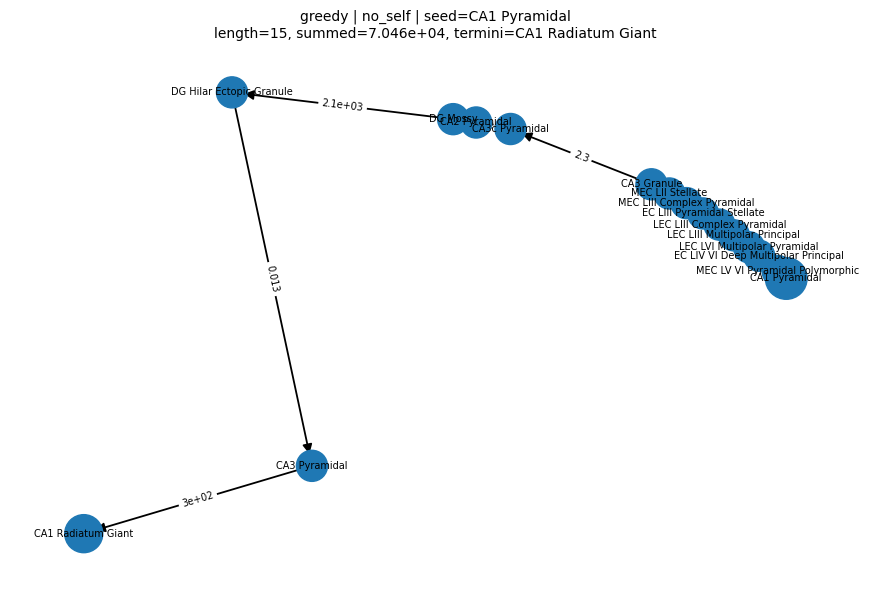

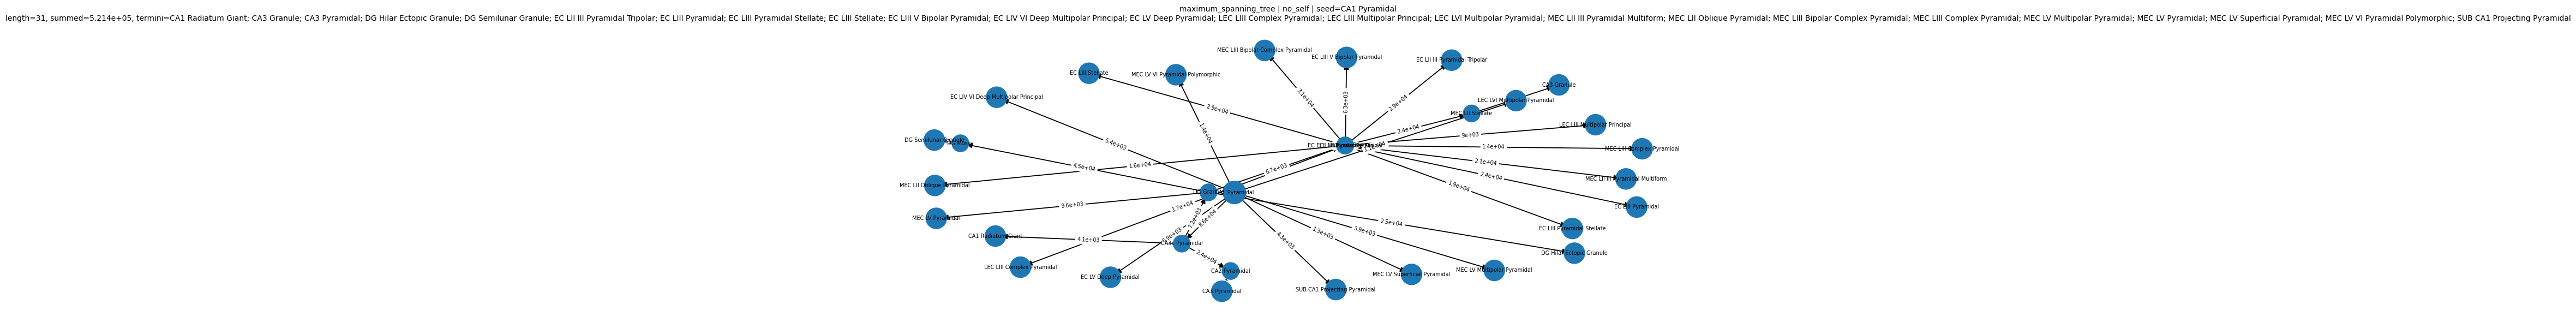

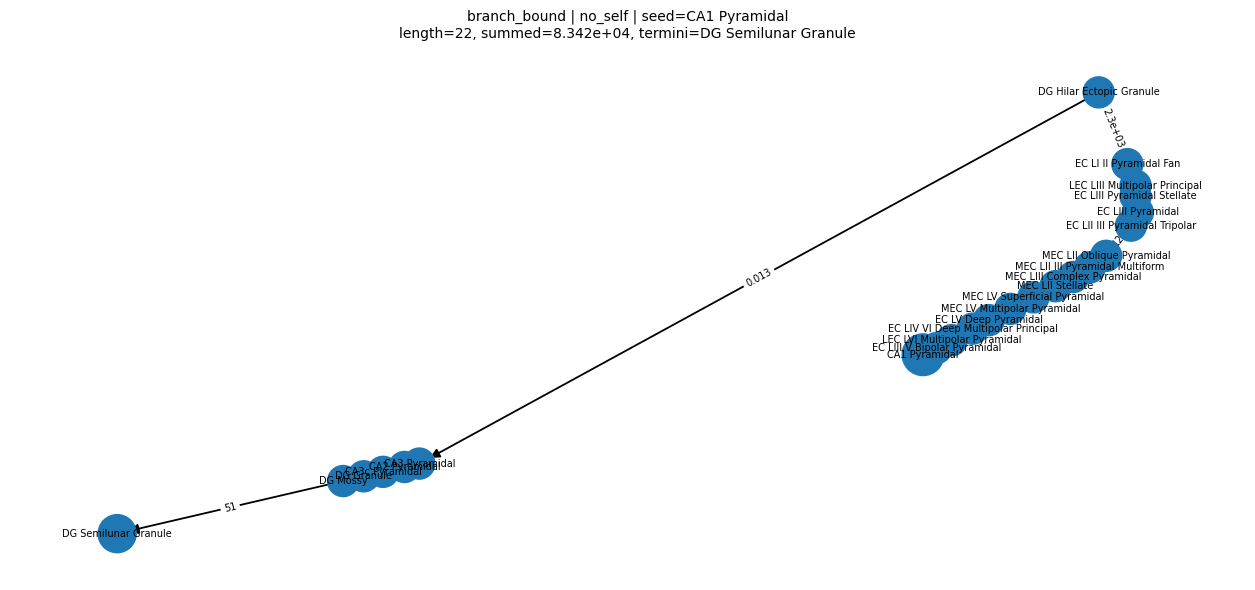

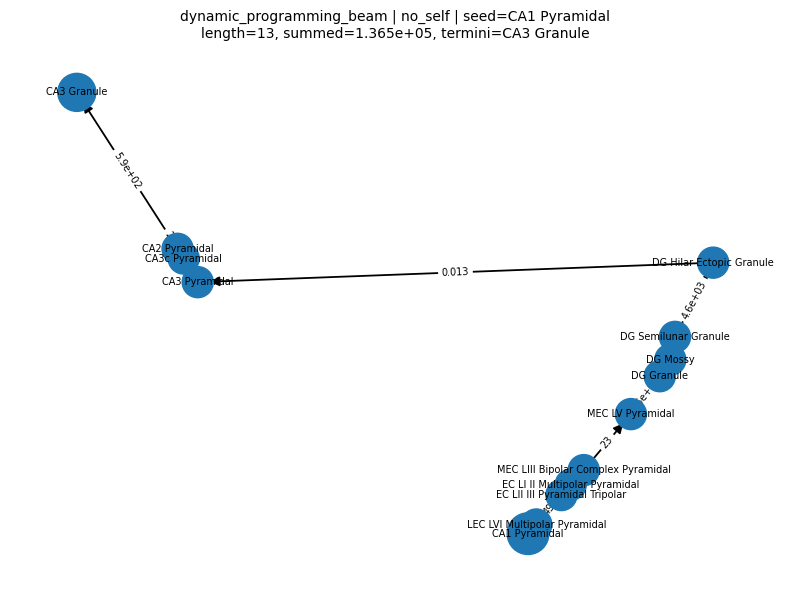

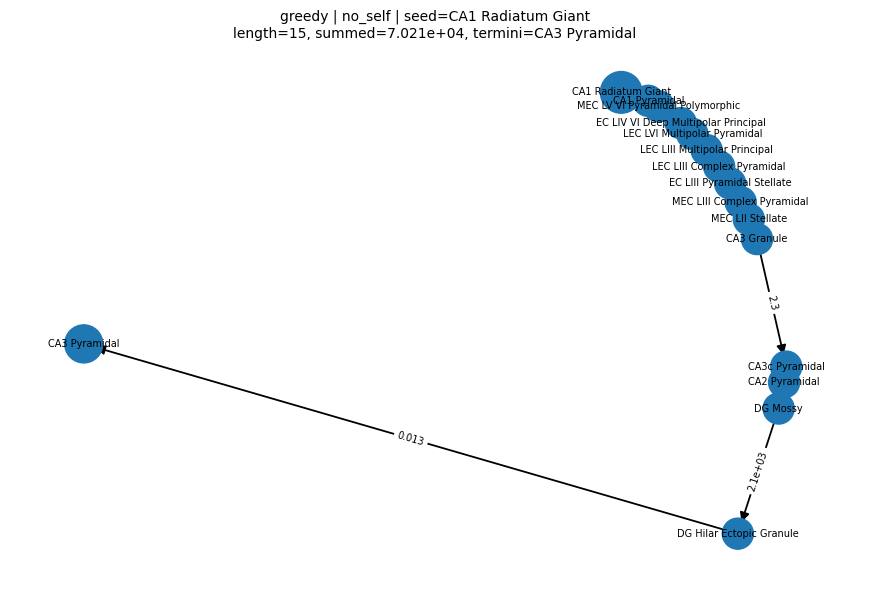

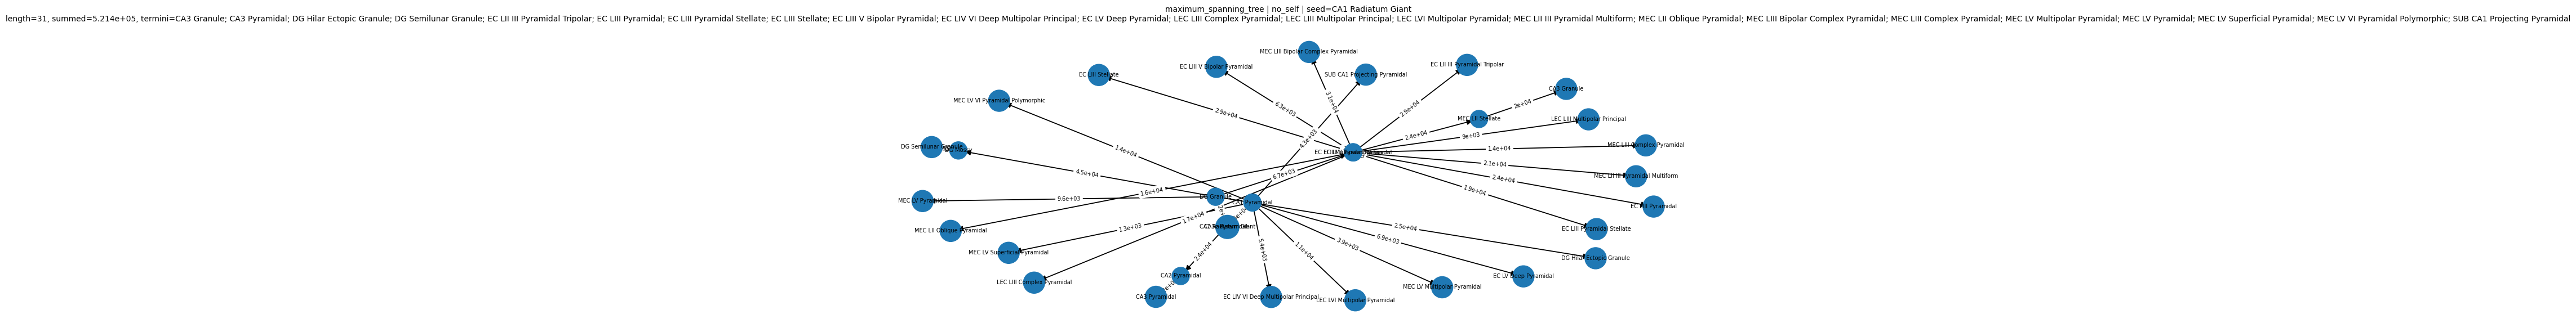

Saved 24 plots to ee_backbone_compare_self_modes/plots


,condition,method,seed,plot_file
0,no_self,greedy,CA1 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...
1,no_self,maximum_spanning_tree,CA1 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...
2,no_self,branch_bound,CA1 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...
3,no_self,dynamic_programming_beam,CA1 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...
4,no_self,greedy,CA1 Radiatum Giant,ee_backbone_compare_self_modes/plots/no_self__...
5,no_self,maximum_spanning_tree,CA1 Radiatum Giant,ee_backbone_compare_self_modes/plots/no_self__...
6,no_self,branch_bound,CA1 Radiatum Giant,ee_backbone_compare_self_modes/plots/no_self__...
7,no_self,dynamic_programming_beam,CA1 Radiatum Giant,ee_backbone_compare_self_modes/plots/no_self__...
8,no_self,greedy,CA2 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...
9,no_self,maximum_spanning_tree,CA2 Pyramidal,ee_backbone_compare_self_modes/plots/no_self__...


In [7]:
def plot_backbone(res, outpath, show=False):
    G=nx.DiGraph()
    for n in res["nodes"]: G.add_node(n)
    for e in res["edges"]: G.add_edge(e["sender"], e["receiver"], weight=e["transition_weight"])
    plt.figure(figsize=(max(8, min(16, 0.55*max(1,len(G.nodes)))), 6))
    pos=nx.spring_layout(G, seed=5, weight="weight") if len(G)>1 else {res["seed"]:(0,0)}
    sizes=[900 if n==res["seed"] else 750 if n in res["termini"] else 500 for n in G.nodes]
    nx.draw_networkx_nodes(G,pos,node_size=sizes)
    nx.draw_networkx_labels(G,pos,font_size=7)
    nx.draw_networkx_edges(G,pos,arrows=True,arrowstyle="-|>",arrowsize=14,width=1.3)
    nx.draw_networkx_edge_labels(G,pos,{(u,v):f"{d['weight']:.2g}" for u,v,d in G.edges(data=True)},font_size=7)
    plt.title(f"{res['method']} | {res['condition']} | seed={res['seed']}\nlength={res['length']}, summed={res['summed_weight']:.4g}, termini={'; '.join(res['termini'])}", fontsize=10)
    plt.axis("off"); plt.tight_layout()
    plt.savefig(outpath,dpi=170,bbox_inches="tight")
    if show: plt.show()
    else: plt.close()

if VISUALIZE_ALL_SEEDS:
    seeds_for_plots=E_nodes
elif VISUALIZE_SEEDS is None:
    seeds_for_plots=E_nodes[:3]
else:
    seeds_for_plots=[s for s in VISUALIZE_SEEDS if s in E_nodes]

plot_rows=[]; shown=0
for res in results:
    if res["seed"] not in seeds_for_plots: continue
    safe="".join(c if c.isalnum() or c in "-_" else "_" for c in res["seed"])[:80]
    p=PLOTDIR/f"{res['condition']}__{res['method']}__{safe}.png"
    plot_backbone(res,p,show=shown<MAX_INLINE_FIGURES)
    shown+=1
    plot_rows.append({"condition":res["condition"],"method":res["method"],"seed":res["seed"],"plot_file":str(p)})
plot_index=pd.DataFrame(plot_rows)
plot_index.to_csv(OUTDIR/"plot_index.csv", index=False)
print(f"Saved {len(plot_index)} plots to {PLOTDIR}")
display(plot_index)


In [8]:
print("Outputs written to:", OUTDIR.resolve())
for f in sorted(OUTDIR.glob("*.csv")):
    print(" -", f.name)


Outputs written to: /mnt/data/ee_backbone_compare_self_modes
 - all_methods_edges.csv
 - greedy_stepwise_paths.csv
 - method_comparison_long.csv
 - method_comparison_wide.csv
 - method_summary.csv
 - node_sign_summary.csv
 - plot_index.csv
 - positive_self_connections.csv
